In [65]:
## conda activate gpy_torch_env
import tqdm
import torch 
from torch.autograd.functional import jacobian
from torch.distributions.multivariate_normal import MultivariateNormal
import gpytorch
import pyro
from pyro.infer import MCMC, NUTS
import pyro.distributions as dist
from scipy.linalg import eigh
import numpy as np 
import matplotlib.pyplot as plt
from scipy.integrate import odeint, solve_ivp
from scipy.stats import norm, multivariate_normal, invgamma, uniform
from scipy import interpolate




## Forward Model

Solve spring problem
\begin{align}
        M x'' + C x' + K x = 0   
    \end{align}

where $M$ is a matrix with the mass values, $C$ is the matrix of dashpot coefficients, and $K$ is the matrix of stiffness parameters. Note that this problem is actually non-identifiable, as the problem can be written as
\begin{align}
        x'' + \tilde{C} x' + \tilde{K} x = 0   
    \end{align}
    where $\tilde{C} = M^{-1}C$ and $\tilde{K} = M^{-1}K$. Thus, we will assume that $M$ is known, but that $C$ and $K$ may be unknown (or convert the system to the second system).



We require the solution of the sensitivity system:
\begin{align}
    \frac{d\chi}{dt} &= \frac{\partial g}{\partial y} \frac{\partial y}{\partial \theta} + \frac{\partial g}{\partial \theta} \\
    &= \frac{\partial g}{\partial u} \chi + \frac{\partial g}{\partial \theta}
    \end{align}
where $\frac{\partial g}{\partial u}$ is the Jacobian of the system, $\bm{\chi}$ is the sensitivity of the states with respect to the parameters, and $\frac{\partial g}{\partial \bm{\theta}}$ are the derivatives with respect to the right hand side expressions. Again for numerical purposes we construct the relative variables for our system, i.e. scaled by the population $N$.

In [66]:


# -----------------------------
# build_M_K_C_and_param_map for chain: wall--k1--m1--k2--m2--...--kN--mN
# -----------------------------
def build_M_K_C_and_param_map_chain(masses, k_springs=None, c_dashpots=None):
    """
    Build M, K, C and parameter mapping for a chain where:
      - there are N masses (masses array length N)
      - there are N springs k_1..k_N where
          k_1 connects wall <-> mass_0 (onsite to mass 0),
          k_i (i>=2) connects mass_{i-2} <-> mass_{i-1} ??? careful:
          (we index masses 0..N-1 and springs 1..N, with spring_i connecting
           mass_{i-1} to mass_{i-1}? No:)
        Interpretation used below:
          spring k_1 connects wall to mass_0
          for i = 2..N: spring k_i connects mass_{i-2}? This is confusing.
    Clarification / chosen convention:
      - masses indexed 0..N-1
      - spring k_1 connects wall <-> mass 0
      - for i = 2..N: spring k_i connects mass (i-2)? NO — choose consistent:
        we'll use:
         "spring k_i connects mass (i-1) to mass (i-2)" would be off-by-one.
      Instead adopt this clear mapping implemented below:
        spring index s = 0..N-1 corresponds to k_{s+1}:
          - s == 0 (k_1): connects wall <-> mass 0
          - s >= 1 (k_{s+1}): connects mass (s-1) <-> mass s
      So springs length = N, dashpots length = N
    Parameters:
      masses: length N array
      k_springs: length N array of spring constants (k1..kN). If None -> zeros.
      c_dashpots: length N array of dashpot constants (c1..cN). If None -> zeros.
    Returns:
      M, K, C, param_names, dM_dp_list, dK_dp_list, dC_dp_list, params_to_MKC
    """
    masses = np.asarray(masses, dtype=float)
    N = masses.size

    if k_springs is None:
        k_springs = np.zeros(N, dtype=float)
    else:
        k_springs = np.asarray(k_springs, dtype=float)
        if k_springs.size != N:
            raise ValueError("k_springs must have length N (same as masses)")

    if c_dashpots is None:
        c_dashpots = np.zeros(N, dtype=float)
    else:
        c_dashpots = np.asarray(c_dashpots, dtype=float)
        if c_dashpots.size != N:
            raise ValueError("c_dashpots must have length N (same as masses)")

    # Mass matrix (diagonal)
    M = np.diag(masses)

    # Stiffness K and Damping C: start zeros
    K = np.zeros((N, N), dtype=float)
    C = np.zeros((N, N), dtype=float)

    # Add spring contributions:
    # spring s=0 (k1) connects wall - mass0: contributes only K[0,0] += k1
    # spring s>=1 (k_{s+1}) connects mass (s-1) and mass s:
    #   K[s-1,s-1] += k, K[s,s] += k; K[s-1,s] -= k; K[s,s-1] -= k
    for s in range(N):
        k_val = k_springs[s]
        if s == 0:
            K[0, 0] += k_val
        else:
            i = s - 1
            j = s
            K[i, i] += k_val
            K[j, j] += k_val
            K[i, j] -= k_val
            K[j, i] -= k_val

    # Add dashpot contributions with same topology
    for s in range(N):
        c_val = c_dashpots[s]
        if s == 0:
            C[0, 0] += c_val
        else:
            i = s - 1
            j = s
            C[i, i] += c_val
            C[j, j] += c_val
            C[i, j] -= c_val
            C[j, i] -= c_val

    # Build parameter list and derivative matrices (dM/dp, dK/dp, dC/dp)
    param_names = []
    dM_dp = []
    dK_dp = []
    dC_dp = []

    # 1) masses (N)
    for i in range(N):
        param_names.append(f"m[{i}]")
        dM = np.zeros((N, N)); dM[i, i] = 1.0
        dM_dp.append(dM)
        dK_dp.append(np.zeros((N, N)))
        dC_dp.append(np.zeros((N, N)))

    # 2) spring constants k1..kN (N)
    for s in range(N):
        param_names.append(f"k[{s+1}]")  # k1..kN
        dM_dp.append(np.zeros((N, N)))
        dK = np.zeros((N, N))
        if s == 0:
            # derivative of K[0,0] wrt k1
            dK[0, 0] = 1.0
        else:
            i = s - 1
            j = s
            dK[i, i] += 1.0
            dK[j, j] += 1.0
            dK[i, j] -= 1.0
            dK[j, i] -= 1.0
        dK_dp.append(dK)
        dC_dp.append(np.zeros((N, N)))

    # 3) dashpot constants c1..cN (N)
    for s in range(N):
        param_names.append(f"c[{s+1}]")  # c1..cN
        dM_dp.append(np.zeros((N, N)))
        dK_dp.append(np.zeros((N, N)))
        dC = np.zeros((N, N))
        if s == 0:
            dC[0, 0] = 1.0
        else:
            i = s - 1
            j = s
            dC[i, i] += 1.0
            dC[j, j] += 1.0
            dC[i, j] -= 1.0
            dC[j, i] -= 1.0
        dC_dp.append(dC)

    # params_to_MKC: reconstruct M,K,C from parameter vector p
    def params_to_MKC(p):
        p = np.asarray(p, dtype=float)
        if p.size != len(param_names):
            raise ValueError("Parameter vector length mismatch: expected {}, got {}".format(len(param_names), p.size))
        Nloc = N
        # build M
        M_loc = np.zeros((Nloc, Nloc), dtype=float)
        offset = 0
        # masses
        for i in range(Nloc):
            M_loc[i, i] = p[offset + i]
        offset += Nloc
        # springs k1..kN
        K_loc = np.zeros((Nloc, Nloc), dtype=float)
        for s in range(Nloc):
            k_val = p[offset + s]
            if s == 0:
                K_loc[0, 0] += k_val
            else:
                i = s - 1
                j = s
                K_loc[i, i] += k_val
                K_loc[j, j] += k_val
                K_loc[i, j] -= k_val
                K_loc[j, i] -= k_val
        offset += Nloc
        # dashpots c1..cN
        C_loc = np.zeros((Nloc, Nloc), dtype=float)
        for s in range(Nloc):
            c_val = p[offset + s]
            if s == 0:
                C_loc[0, 0] += c_val
            else:
                i = s - 1
                j = s
                C_loc[i, i] += c_val
                C_loc[j, j] += c_val
                C_loc[i, j] -= c_val
                C_loc[j, i] -= c_val
        return M_loc, K_loc, C_loc

    return M, K, C, param_names, dM_dp, dK_dp, dC_dp, params_to_MKC



In [67]:
# -----------------------------
# build_Jy_and_Jp (same pattern but uses new derivatives)
# -----------------------------
def build_Jy_and_Jp_chain(y, p, M, K, C, dM_dp_list, dK_dp_list, dC_dp_list):
    """
    Build Jacobian J_y and J_p for the chain model.
    y: state (2N,) = [x (N), v (N)]
    p: parameter vector (length P)
    M,K,C: current matrices (N,N)
    dM_dp_list, dK_dp_list, dC_dp_list: lists of (N,N) arrays length P
    Returns:
      A (2N x 2N) = d f / d y
      B (2N x P) = d f / d p
    Dynamics:
      y' = [ v ;
             - M^{-1} (C v + K x) ]
    """
    N = M.shape[0]
    P = len(dM_dp_list)
    x = y[:N]
    v = y[N:]

    Minv = np.linalg.inv(M)
    w = C.dot(v) + K.dot(x)   # N-vector

    # Build A
    A = np.zeros((2*N, 2*N), dtype=float)
    # top-right block
    A[0:N, N:2*N] = np.eye(N)
    # bottom-left: d/dx of -M^{-1}(K x + C v) = -M^{-1} K
    A[N:2*N, 0:N] = - Minv.dot(K)
    # bottom-right: d/dv = -M^{-1} C
    A[N:2*N, N:2*N] = - Minv.dot(C)

    # Build B (2N x P)
    B = np.zeros((2*N, P), dtype=float)
    # top rows zeros
    for j in range(P):
        dM = dM_dp_list[j]
        dK = dK_dp_list[j]
        dC = dC_dp_list[j]
        # term1: + M^{-1} dM M^{-1} w  (result of - d(M^{-1}) w)
        term1 = Minv.dot(dM).dot(Minv).dot(w) if np.any(dM) else np.zeros(N)
        # term2: - M^{-1} ( dC v + dK x )
        term2 = - Minv.dot(dC.dot(v) + dK.dot(x)) if (np.any(dC) or np.any(dK)) else np.zeros(N)
        B[N:2*N, j] = term1 + term2

    return A, B

# -----------------------------
# augmented_rhs for integrator
# -----------------------------
def augmented_rhs_chain(t, Y_aug, p, params_to_MKC, dM_dp_list, dK_dp_list, dC_dp_list):
    """
    Augmented RHS for combined state and sensitivities for the chain model.

    Y_aug = [ y (2N,), vec(S) (2N*P,) ] where vec stacks columns (Fortran order used).
    p is fixed parameter vector (we compute linearization w.r.t p)
    """
    P = len(dM_dp_list)
    N = dM_dp_list[0].shape[0]

    y = Y_aug[:2*N]
    S_vec = Y_aug[2*N:]
    S = S_vec.reshape((2*N, P), order='F')

    # current matrices from p
    M, K, C = params_to_MKC(p)

    # compute Jy and Jp
    A, B = build_Jy_and_Jp_chain(y, p, M, K, C, dM_dp_list, dK_dp_list, dC_dp_list)

    # compute y_dot
    x = y[:N]; v = y[N:]
    Minv = np.linalg.inv(M)
    y_dot = np.zeros(2*N, dtype=float)
    y_dot[:N] = v
    y_dot[N:] = - Minv.dot(C.dot(v) + K.dot(x))

    # sensitivity ODE: S_dot = A S + B
    S_dot = A.dot(S) + B

    return np.concatenate([y_dot, S_dot.reshape((2*N*P,), order='F')])

# -----------------------------
# simulate_with_sensitivities for chain
# -----------------------------
def simulate_with_sensitivities(masses, k_springs=None, c_dashpots=None,
                                      y0=None, p0=None, t_span=(0.0, 10.0), t_eval=None):
    """
    Build chain system and simulate dynamics together with sensitivities.

    Parameters:
      masses: array length N
      k_springs: array length N (k1..kN, k1 connects wall to mass0)
      c_dashpots: array length N (c1..cN)
      y0: initial state (2N,) default zeros
      p0: parameter vector in order [masses (N), k_springs (N), c_dashpots (N)]
      t_span: (t0, tf)
      t_eval: optional time points
    Returns:
      sol: ode result
      param_names: list of parameter names
      y_time: array (T, 2N)
      S_time: array (T, 2N, P)
    """
    M0, K0, C0, param_names, dM_dp, dK_dp, dC_dp, params_to_MKC = \
        build_M_K_C_and_param_map_chain(masses, k_springs, c_dashpots)

    P = len(param_names)
    N = M0.shape[0]

    # assemble nominal p0 if not provided: [masses, k_springs, c_dashpots]
    if p0 is None:
        k_springs_val = np.zeros(N) if k_springs is None else np.asarray(k_springs)
        c_dashpots_val = np.zeros(N) if c_dashpots is None else np.asarray(c_dashpots)
        p_list = []
        p_list.extend(list(masses))
        p_list.extend(list(k_springs_val))
        p_list.extend(list(c_dashpots_val))
        p0 = np.array(p_list, dtype=float)
    else:
        p0 = np.asarray(p0, dtype=float)
        if p0.size != P:
            raise ValueError("p0 length {} doesn't match expected P {}".format(p0.size, P))

    # initial state
    if y0 is None:
        y0 = np.zeros(2*N, dtype=float)
    y0 = np.asarray(y0, dtype=float)
    if y0.size != 2*N:
        raise ValueError("y0 must have length 2N")

    # initial sensitivities S0 = zeros unless initial cond depend on p
    S0 = np.zeros((2*N, P), dtype=float)
    Y0_aug = np.concatenate([y0, S0.reshape((2*N*P,), order='F')])

    # define rhs closure
    def rhs_aug(t, Y_aug):
        return augmented_rhs_chain(t, Y_aug, p0, params_to_MKC, dM_dp, dK_dp, dC_dp)

    sol = solve_ivp(rhs_aug, t_span=t_span, y0=Y0_aug, t_eval=t_eval, method='RK45', atol=1e-8, rtol=1e-6)
    if not sol.success:
        raise RuntimeError("Integrator failed: " + sol.message)

    T = sol.y.shape[1]
    y_time = sol.y[:2*N, :].T  # (T, 2N)
    S_time = np.zeros((T, 2*N, P), dtype=float)
    for ti in range(T):
        S_vec = sol.y[2*N:, ti]
        S_time[ti, :, :] = S_vec.reshape((2*N, P), order='F')

    return sol, param_names, y_time, S_time





In [68]:
## Here is add some interesting dynamics to the system by letting the first and last spring be offset.
def call_spring_model_fixedM(t_eval,masses,k_vals,c_vals,jac_flag):
    
    N = np.size(masses)
    # initial localized displacement on mass 0
    x0 = np.zeros(N)
    x0[0] = 5.0
    x0[-1] = -5.0
    v0 = np.zeros(N)
    y0 = np.hstack((x0, v0))
    NT = len(t_eval)
    
    sol, param_names, y_time, S_time = simulate_with_sensitivities(
    masses, k_vals, c_vals, y0=y0, p0=None, t_span=(t_eval[0], t_eval[-1]), t_eval=t_eval)
    n_param_sens = np.shape(param_names)[0]-N #subtract N mass sensitivities
    if (jac_flag==0):
        x = torch.tensor(y_time[:,:N]).reshape(NT,N)
        Sx = torch.tensor(S_time[:,:N,N:]).reshape(NT,N*n_param_sens)
        return t_eval,torch.cat([x,Sx], dim=1),param_names[N:]
    else:
        return t_eval,torch.tensor(S_time[:,:N,N:]).reshape(NT,N,n_param_sens)

In [69]:
N = 3
masses = 5.0 * np.ones(N)
# k_vals = 2.6 * np.ones(N)
# c_vals = 2.1 * np.ones(N)
k_vals = np.array((2.6, 3.2, 4.1))
c_vals = np.array((2.1, 5.1, 3.4))
t0, tf = 0.0, 30.0
dt = 0.01
t_eval = np.arange(t0, tf+dt, dt)



t, output,param_names = call_spring_model_fixedM(t_eval,masses,k_vals,c_vals,0)


0
1
2
3
4
5


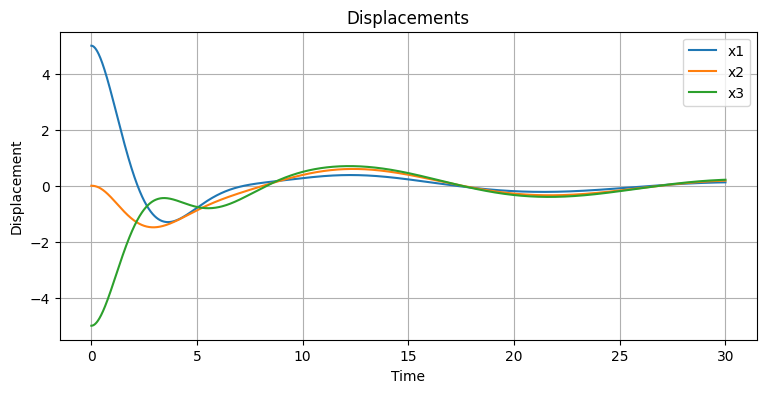

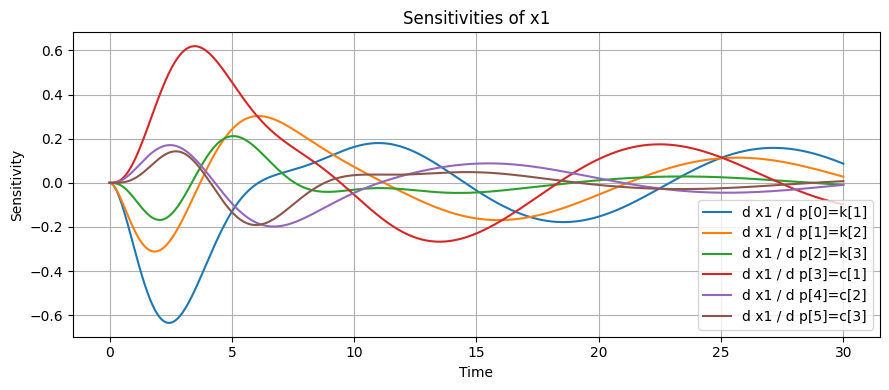

In [70]:
# Example: plot displacement of first 3 masses
plt.figure(figsize=(9,4))
for i in range(min(3,N)):
    plt.plot(t, output[:,i], label=f"x{i+1}")
plt.xlabel("Time"); plt.ylabel("Displacement"); plt.title("Displacements")
plt.legend(); plt.grid(True)

# Example: plot sensitivity of x1 w.r.t. first few parameters (e.g., its own mass and k_on0)
plt.figure(figsize=(9,4))
pplot = list(range(len(param_names)))
for pj in pplot:
    print(pj)
    plt.plot(t, output[:,N+pj], label=f"d x1 / d p[{pj}]={param_names[pj]}")
plt.xlabel("Time"); plt.ylabel("Sensitivity"); plt.title("Sensitivities of x1")
plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()

# Multivariate Orthogonal GP

In [71]:
# Set up model structure for the springs
N = 3
masses_true = masses
k_vals_true = k_vals
c_vals_true = c_vals

# When mass is free
# theta_true = torch.tensor(np.concat([masses_true,k_on_true,[k_couple_true],c_on_true,[c_couple_true]]),dtype=torch.float32)
# When mass is fixed
theta_true = torch.tensor(np.concat([k_vals_true,c_vals_true]),dtype=torch.float32)

t0, tf = 0.0, 30.0
x = torch.linspace(0,10,100).to(dtype=torch.float32)
t_eval = x
t, output,param_names = call_spring_model_fixedM(t_eval, masses_true,k_vals_true,c_vals_true,0)
npar = len(param_names)

print(param_names)

['k[1]', 'k[2]', 'k[3]', 'c[1]', 'c[2]', 'c[3]']


In [72]:
def computeJitter(Cmat, target_min_eigval, min_jitter):
    eigvals = torch.linalg.eigvalsh(Cmat)
    lambda_min = eigvals.min()
    required_jitter = torch.clamp(target_min_eigval - lambda_min, min=min_jitter).item()
    return required_jitter  

def compute_jacobian(theta,x):
        # Break Jacobian into numerical solution of system 
        masses = masses_true#theta[0:N].detach().numpy()
        k_vals = theta[0:N].detach().numpy()#theta[N:2*N].detach().numpy()
        c_vals = theta[N:].detach().numpy()#theta[2*N].detach().numpy()
        
        t, jac = call_spring_model_fixedM(x, masses,k_vals,c_vals,1)
        # f1,f2,s11,s21,s12,s22 = solution.T
        # print(np.size(Smu,axis=0))
        return jac.to(dtype=torch.float32)

class MultivariateOrthogonalKernel(torch.nn.Module):
    def __init__(self, C_func, call_model, gamma=1e-1, target_min_eigval=None, min_jitter=1e-10):
        super().__init__()
        self.J = C_func.num_tasks
        self.C_func = C_func
        # self.fmodel = fmodel
        self.fmodel = call_model
        self.gamma = gamma
        self.target_min_eigval = target_min_eigval
        self.min_jitter = min_jitter
    
    def forward(self, x, theta, xvol=None):
        n = len(x)
        if not xvol:
            xvol = 1./n
        C_x = self.gamma*self.C_func(x).evaluate().view(n, self.J, n, self.J).permute(0, 2, 1, 3) 
        J_theta_x = compute_jacobian(theta,x)#jacobian(lambda th: self.fmodel(x, th), theta) ## n x J x P
        h_theta_x_trans = xvol*torch.sum(torch.matmul(C_x, J_theta_x.unsqueeze(0)),dim=1)
        H_theta_inv = torch.linalg.inv(xvol*xvol*torch.sum(torch.matmul(J_theta_x.permute(0, 2, 1).unsqueeze(1), 
                                                   torch.matmul(C_x, J_theta_x.unsqueeze(0))),
                                        dim=(0, 1)))
        C_delta_x = C_x - torch.einsum("aip,pq,bjq->abij", h_theta_x_trans, H_theta_inv, h_theta_x_trans) # This is bZ
        C_delta_x_flat = C_delta_x.permute(0, 2, 1, 3).reshape(n * J, n * J)
        C_delta_x_flat = (C_delta_x_flat + C_delta_x_flat.T)/2.
        ##note, einsum implements
        #for i1 in range(n):
        #    for i2 in range(n):
        #        [i1, i2, ...] = h_theta_x_trans[i1,...] @ H_theta @ h_theta_x_trans[i2,...].T
        ## add jitter for numerical stabalization 
        if self.target_min_eigval:
            required_jitter = computeJitter(C_delta_x_flat, self.target_min_eigval, self.min_jitter)
            C_delta_x_flat = C_delta_x_flat + required_jitter * torch.eye(n*J)
        return C_delta_x_flat

In [73]:
## define orthogonal discrepancy prior 
J = N
gamma_true = 0.05# was 0.01
bw_param_true = 0.8# Was 0.5
marg_kernel = gpytorch.kernels.RBFKernel()
marg_kernel.lengthscale = torch.tensor(bw_param_true)
marg_kernel.raw_lengthscale.requires_grad = False
## numerical stability 
target_min_eigval = 1e-6
min_jitter = 1e-10 

Cov_unc = gpytorch.kernels.MultitaskKernel(marg_kernel, num_tasks=J) ## eval -> nJ x nJ (need to reshape)
Cov_delta_theta = MultivariateOrthogonalKernel(Cov_unc, call_spring_model_fixedM, gamma=gamma_true, 
                                                    target_min_eigval=target_min_eigval, min_jitter=min_jitter)
C_delta_theta_true_xobs_flat = Cov_delta_theta(x, theta_true)

delta_ortho_theta_true_prior = MultivariateNormal(torch.zeros(len(x) * J), C_delta_theta_true_xobs_flat)

## add jitter for numerical stabality in unconstrained case
C_x_flat = gamma_true*Cov_unc(x).evaluate()
jitter = computeJitter(C_x_flat, target_min_eigval, min_jitter)
C_x_flat = C_x_flat + jitter*torch.eye(len(x)*J)
delta_unconstr_prior = MultivariateNormal(torch.zeros(len(x) * J), C_x_flat)
                                                                                  

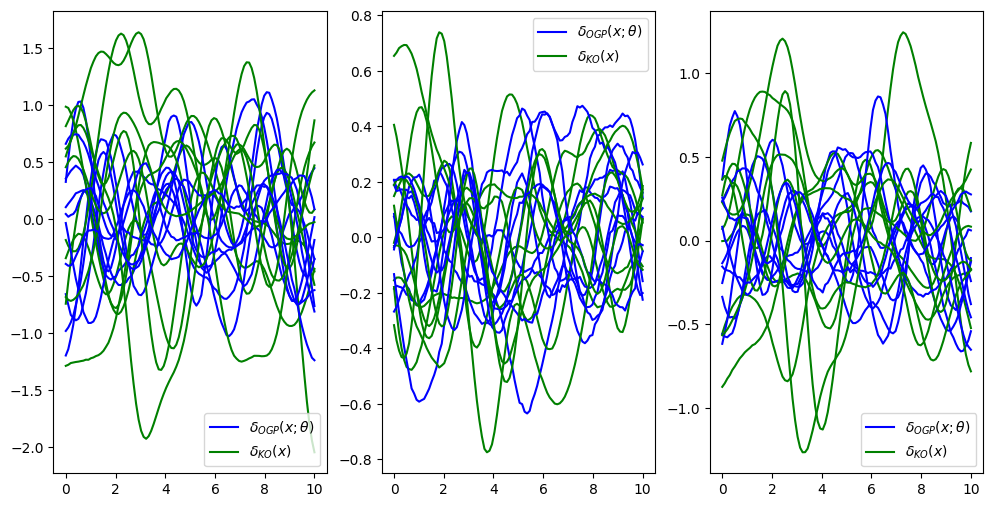

In [74]:
## compare to unrestricted prior  
delta_orth_sample = delta_ortho_theta_true_prior.rsample((10,)).view(10, len(x), J)
delta_uncon_sample =delta_unconstr_prior.rsample((10,)).view(10, len(x), J)


if (N>1):
    f, ax = plt.subplots(1,N,figsize=(12,6))
    for i in range(10):  
        for j in range(N):
            ax[j].plot(x.numpy(), delta_orth_sample[i, :, j].detach().numpy(), 
                                label=r'$\delta_{OGP}(x; \theta)$' if i == 0 else "", c="b")
            ax[j].plot(x.numpy(), delta_uncon_sample[i, :, j].detach().numpy(), 
                                    label=r'$\delta_{KO}(x)$' if i == 0 else "", c="g")
            ax[j].legend()
else:
    plt.figure()
    for i in range(10):  
        plt.plot(x.numpy(), delta_orth_sample[i, :].detach().numpy(), 
                            label=r'$\delta(x; \theta)$' if i == 0 else "", c="b")
        plt.plot(x.numpy(), delta_uncon_sample[i, :].detach().numpy(), 
                                label=r'$\delta_1(x)$' if i == 0 else "", c="g")
    plt.legend()
    

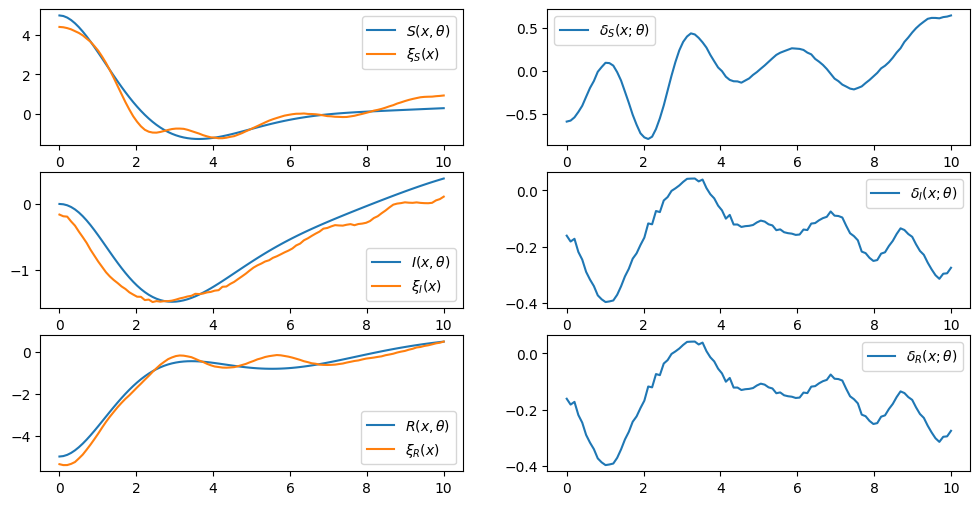

In [75]:
torch.manual_seed(200)
## sample true discrepancy
delta_disc_true = delta_ortho_theta_true_prior.rsample((1,)).view(len(x), J)
## Defined the true phyiscal process 
t, output,param_names = call_spring_model_fixedM(x,masses_true,k_vals_true,c_vals_true,0)
f_true = output[:,0:N]
xi_true = f_true + delta_disc_true

## plot optimally calibrated model + true phyiscal process, zzzzzzzzz
fig, ax = plt.subplots(3,2,figsize=(12,6))

ax[0,0].plot(x.numpy(), f_true[:, 0].detach().numpy(), label=r'$S(x,\theta)$')
ax[0,0].plot(x.numpy(), xi_true[:, 0].detach().numpy(), label=r'$\xi_S(x)$')


ax[1,0].plot(x.numpy(), f_true[:, 1].detach().numpy(), label=r'$I(x,\theta)$')
ax[1,0].plot(x.numpy(), xi_true[:, 1].detach().numpy(), label=r'$\xi_I(x)$')
ax[2,0].plot(x.numpy(), f_true[:, 2].detach().numpy(), label=r'$R(x,\theta)$')
ax[2,0].plot(x.numpy(), xi_true[:, 2].detach().numpy(), label=r'$\xi_R(x)$')

ax[0,1].plot(x.numpy(), delta_disc_true[:, 0].detach().numpy(), label=r'$\delta_S(x; \theta)$')
ax[1,1].plot(x.numpy(), delta_disc_true[:, 1].detach().numpy(), label=r'$\delta_I(x; \theta)$')
ax[2,1].plot(x.numpy(), delta_disc_true[:, 1].detach().numpy(), label=r'$\delta_R(x; \theta)$')

ax[0,0].legend()
ax[1,0].legend()
ax[2,0].legend()
ax[0,1].legend()
ax[1,1].legend()
ax[2,1].legend()

# Statistical Inference

In [76]:
## observation model 
n_obs = 30
x_obs = torch.linspace(0.0, x[-1], n_obs)

## local interpolation from discretized function repreresentation
xi_1_interp = interpolate.interp1d(x.detach().numpy(), xi_true[:,0].detach().numpy())
xi_2_interp = interpolate.interp1d(x.detach().numpy(), xi_true[:,1].detach().numpy())
xi_3_interp = interpolate.interp1d(x.detach().numpy(), xi_true[:,2].detach().numpy())

xi_obs = torch.cat((torch.from_numpy(xi_1_interp(x_obs.detach().numpy())).float().view(-1,1),
                    torch.from_numpy(xi_2_interp(x_obs.detach().numpy())).float().view(-1,1),
                    torch.from_numpy(xi_3_interp(x_obs.detach().numpy())).float().view(-1,1)
                    ),
                    dim=-1)

## iid measurement error 
sigma_e = 0.1
y_obs = xi_obs + torch.normal(0, sigma_e, size=(n_obs,N))

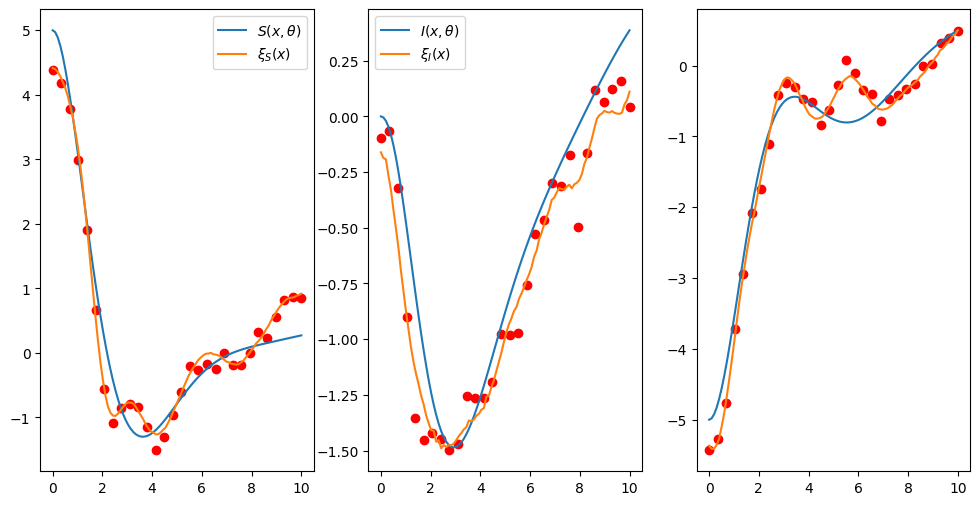

In [77]:
## plot optimally calibrated model + true phyiscal process, 
fig, ax = plt.subplots(1,3,figsize=(12,6))

ax[0].plot(x.numpy(), f_true[:, 0].detach().numpy(), label=r'$S(x,\theta)$')
ax[0].plot(x.numpy(), xi_true[:, 0].detach().numpy(), label=r'$\xi_S(x)$')
ax[0].scatter(x_obs.numpy(), y_obs[:, 0].detach().numpy(), c="r")

ax[1].plot(x.numpy(), f_true[:, 1].detach().numpy(), label=r'$I(x,\theta)$')
ax[1].plot(x.numpy(), xi_true[:, 1].detach().numpy(), label=r'$\xi_I(x)$')
ax[1].scatter(x_obs.numpy(), y_obs[:, 1].detach().numpy(), c="r")

ax[2].plot(x.numpy(), f_true[:, 2].detach().numpy(), label=r'$R(x,\theta)$')
ax[2].plot(x.numpy(), xi_true[:, 2].detach().numpy(), label=r'$\xi_R(x)$')
ax[2].scatter(x_obs.numpy(), y_obs[:, 2].detach().numpy(), c="r")


ax[0].legend()
ax[1].legend()
# ax[2].legend()

In [78]:
 ## numerical stability 
target_min_eigval = 1e-6
min_jitter = 1e-10 
marg_kernel = gpytorch.kernels.RBFKernel()
marg_kernel.initialize(lengthscale=torch.tensor(bw_param_true))
marg_kernel.raw_lengthscale.requires_grad = False   # freeze it if needed
GP_Cov_unc = gpytorch.kernels.MultitaskKernel(marg_kernel, num_tasks=J) ## eval -> nJ x nJ (need to reshape)
GP_Cov_unc.data_covar_module.initialize(lengthscale=torch.tensor(bw_param_true))
GP_Cov_unc.data_covar_module.raw_lengthscale.requires_grad = False

GP_Cov_MOP = MultivariateOrthogonalKernel(Cov_unc, call_spring_model_fixedM, gamma=gamma_true, 
                                                target_min_eigval=target_min_eigval, min_jitter=min_jitter)
## inference

def potential_fn_MOP(theta,GPtheta,GP_cov,s2):
   
    # Gaussian Process for discrepancy term
    gamma,bw = GPtheta
   #  marg_kernel.lengthscale = torch.tensor(bw)
   #  Cov_unc = gpytorch.kernels.MultitaskKernel(marg_kernel, num_tasks=J) ## eval -> nJ x nJ (need to reshape)
   #  Cov_delta_theta = MultivariateOrthogonalKernel(Cov_unc, call_spring_model, gamma=gamma, 
   #                                                  target_min_eigval=target_min_eigval, min_jitter=min_jitter)
    GP_cov.C_func.data_covar_module.raw_lengthscale.copy_(torch.tensor([bw]))
    GP_cov.gamma = gamma
    # Gaussian Process for discrepancy term
    C_delta_theta_true_xobs_flat = GP_cov(x_obs, theta)
    Cov = C_delta_theta_true_xobs_flat + (s2)*torch.eye(n_obs*J)
    ## forward model 
    # f_x_flat = fmodel_MJC(x_obs, theta).view(n_obs*J)
    masses = masses_true#theta[0:N].detach().numpy()
    k_vals = theta[0:N].detach().numpy()#theta[N:2*N].detach().numpy()
    c_vals = theta[N:].detach().numpy()#theta[N:2*N].detach().numpy()
    t, y_all, names = call_spring_model_fixedM(x_obs, masses,k_vals,c_vals,0)
    states = torch.transpose(torch.reshape(y_all[:,:N],(N,len(x_obs))),0,1)
    f_x_flat = states.reshape(n_obs*J)

    ## posterior density (MJC: added try statement here because I kept getting non-SPD covariances)
    try:
       post_density = dist.MultivariateNormal(f_x_flat, Cov)
       PD_value = post_density.log_prob(y_obs.view(n_obs*J)) # EQ 17 IN OUR METHODS
       SS = torch.sum((y_obs.view(n_obs*J)-f_x_flat)**2)
    except:
       PD_value = torch.tensor(-torch.inf)
       SS = torch.inf
    return PD_value, SS

def potential_fn_IND(theta,GPtheta,GP_cov,s2):
    # Gaussian Process for discrepancy term
    gamma,bw = GPtheta
    GP_cov.data_covar_module.raw_lengthscale.copy_(torch.tensor([bw]))

    # Gaussian Process for discrepancy term
    Cov = gamma*Cov_unc(x_obs).evaluate() + (s2)*torch.eye(n_obs*J)
    ## forward model 
    # f_x_flat = fmodel_MJC(x_obs, theta).view(n_obs*J)
    masses = masses_true#theta[0:N].detach().numpy()
    k_vals = theta[0:N].detach().numpy()#theta[N:2*N].detach().numpy()
    c_vals = theta[N:].detach().numpy()#theta[N:2*N].detach().numpy()
    t, y_all, names = call_spring_model_fixedM(x_obs, masses,k_vals,c_vals,0)
    states = torch.transpose(torch.reshape(y_all[:,:N],(N,len(x_obs))),0,1)
    f_x_flat = states.reshape(n_obs*J)
    # print(f_x_flat)
    ## posterior density 
    post_density = dist.MultivariateNormal(f_x_flat, Cov)
    SS = torch.sum((y_obs.view(n_obs*J)-f_x_flat)**2)
    return post_density.log_prob(y_obs.view(n_obs*J)), SS
    



In [97]:
def adaptive_metropolis(post_func, data, theta0, s20, k0, M, covar, UB, LB, GP_cov):
    # Note: I removed the prior from this because we have uniform priors on theta and fixed discrepancy
    n_par = len(theta0)
    chain = torch.zeros((n_par, M))
    lik_chain = torch.zeros(M,1)
    s2chain = torch.zeros(M,1)
    n_y = len(data)
    print(n_y)

    if covar is None or len(covar) == 0:
        covar = torch.eye(n_par) * 0.1 * torch.abs(theta0)
    
    def lik_func(theta,thetaGP,s2):
        return post_func(theta,thetaGP,GP_cov,s2)
    
    chain[:, 0] = theta0
    thetamodel = theta0[:n_par-2]
    thetaGP    = np.exp(theta0[n_par-2:])
    lik_old, ss_old = lik_func(thetamodel,thetaGP,s20)
    sig_s = ss_old / (n_y - n_par)  # Estimate of error variance
    R = torch.linalg.cholesky(covar)
    print(thetamodel,thetaGP,ss_old,sig_s)


    # Error variance hyperparameters
    n_s = 0.01  # For inverse gamma
    aval = 0.5 * (n_s + n_y)  # This is constant
    bval = 0.5 * (n_s * sig_s + ss_old)
    s2chain[0] = invgamma.rvs(aval, scale=bval)
    # print(s2chain[0])
    # Initialize covariance estimates
    Vk = covar
    theta_bar = theta0
    Ip = torch.eye(n_par) * 1e-12  # Small jitter on diagonal for stability
    sp_cov = (2.38 ** 2) / n_par

    num_acc = 0
    prob_acc = np.log(uniform.rvs(size=M))
    for i in range(1, M):
        # given discrepancy value previously, compute log-likelihood with covariance given by
        # the MOP approach
        theta_star = chain[:, i - 1] + R.T.detach() @ np.random.normal(0, 1, n_par)

        if torch.sum(theta_star>UB).detach()>0 or torch.sum(theta_star<LB).detach()>0:
            lik_star = torch.inf
            acc_prob = -torch.inf
            ss_star = torch.inf
        else:
            thetamodel = theta_star[0:n_par-2]
            thetaGP    = np.exp(theta_star[n_par-2:])
            lik_old, ss_old   = lik_func(chain[0:n_par-2,i-1],np.exp(chain[n_par-2:,i-1]),s2chain[i-1])
            lik_star, ss_star = lik_func(thetamodel,thetaGP,s2chain[i-1])
            # if torch.abs(lik_star)>1e10:
                # acc_prob = 0.0
            # else:
            acc_prob = (lik_star) - (lik_old)
              # Recompute for the same s2 value
        
        
        if acc_prob > prob_acc[i]:
            ss_old = ss_star
            chain[:, i] = theta_star
            lik_old = lik_star
            num_acc += 1
        else:
            chain[:, i] = chain[:, i - 1]
            
        lik_chain[i]=lik_old

        # Gibbs step on hyperparameter
        bval = 0.5 * (n_s * sig_s + ss_old)
        s2chain[i] = np.minimum(invgamma.rvs(aval, scale=bval),1e4)
        # print(acc_prob,prob_acc[i],s2chain[i])

        if i % 500 == 0:
            print('Percent done:',i/M*100)
            print('Acceptance rate:')
            print((num_acc / i) * 100)
        # Update covariance and mean parameter
        theta_bar_old = theta_bar
        theta_bar = (i / (i + 1)) * theta_bar_old + chain[:, i] / (i + 1)
        Vk = ((i - 1) * Vk / i + (sp_cov / i) * (i * torch.outer(theta_bar_old, theta_bar_old) -
             (i + 1) * torch.outer(theta_bar, theta_bar) + torch.outer(chain[:, i], chain[:, i]) + Ip))
        
        if i % k0 == 0:  # Update covariance in sampling
            Vk = 0.5*(Vk+Vk.T)+1e-12*np.eye(n_par)
            R = torch.linalg.cholesky(Vk)

    print('Acceptance rate:')
    print((num_acc / M) * 100)
    print(Vk)

    return chain, lik_chain, s2chain

In [98]:
print(gamma_true,bw_param_true)

0.05 0.8


In [99]:
UB = 8*torch.ones(len(param_names))
LB = 0*torch.ones(len(param_names))
UB = torch.cat((UB, torch.tensor([np.log(gamma_true*1.1), np.log(bw_param_true*1.1)])))
LB = torch.cat((LB, torch.tensor([np.log(gamma_true*0.9), np.log(bw_param_true*0.9)])))
theta0 = torch.cat((theta_true,torch.tensor([np.log(gamma_true),np.log(bw_param_true)])))

num_par = len(theta0)
print(UB)
print(theta0)
print(LB)

k0 = 10000 # make this less than M to actually make this the AM; otherwise its MH
M = 5000
covar = torch.eye(len(theta0)) * 0.0001 * torch.abs(theta0)
print(torch.diag(covar))

tensor([ 8.0000,  8.0000,  8.0000,  8.0000,  8.0000,  8.0000, -2.9004, -0.1278],
       dtype=torch.float64)
tensor([ 2.6000,  3.2000,  4.1000,  2.1000,  5.1000,  3.4000, -2.9957, -0.2231],
       dtype=torch.float64)
tensor([ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000, -3.1011, -0.3285],
       dtype=torch.float64)
tensor([2.6000e-04, 3.2000e-04, 4.1000e-04, 2.1000e-04, 5.1000e-04, 3.4000e-04,
        2.9957e-04, 2.2314e-05], dtype=torch.float64)


In [100]:

chain_IND, lik_chain_IND,s2chain_IND = adaptive_metropolis(post_func=potential_fn_IND, data=y_obs.view(n_obs*J), theta0=theta0, s20=sigma_e**2, k0=k0, M=M, covar=covar, UB=UB, LB=LB, GP_cov=GP_Cov_unc)

90
tensor([2.6000, 3.2000, 4.1000, 2.1000, 5.1000, 3.4000], dtype=torch.float64) tensor([0.0500, 0.8000], dtype=torch.float64) tensor(343.1659, dtype=torch.float64) tensor(4.1849, dtype=torch.float64)


C:\Users\colebanm\AppData\Local\Temp\ipykernel_29208\1967601215.py:18: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  thetaGP    = np.exp(theta0[n_par-2:])
C:\Users\colebanm\AppData\Local\Temp\ipykernel_29208\1967601215.py:42: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  theta_star = chain[:, i - 1] + R.T.detach() @ np.random.normal(0, 1, n_par)
C:\Users\colebanm\AppData\Local\Temp\ipykernel_29208\1967601215.py:50: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  thetaGP    = np.exp(theta_star[n_par-2:])
C:\Users\colebanm\AppData\Local\Temp\ipykernel_29208\1967601215.py:51: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  lik_old,

Percent done: 10.0
Acceptance rate:
88.8
Percent done: 20.0
Acceptance rate:
87.8
Percent done: 30.0
Acceptance rate:
88.8
Percent done: 40.0
Acceptance rate:
89.85
Percent done: 50.0
Acceptance rate:
90.36
Percent done: 60.0
Acceptance rate:
89.96666666666667
Percent done: 70.0
Acceptance rate:
89.8
Percent done: 80.0
Acceptance rate:
89.7
Percent done: 90.0
Acceptance rate:
89.35555555555555
Acceptance rate:
89.44
tensor([[ 6.4764e-02, -7.8403e-02, -4.7309e-03,  1.6334e-02, -1.5481e-01,
         -5.2137e-02,  9.4134e-04, -6.5577e-04],
        [-7.8403e-02,  2.8035e-01, -3.8119e-02, -4.8479e-02,  2.5486e-01,
          1.3148e-01, -2.5445e-03, -1.9141e-03],
        [-4.7309e-03, -3.8119e-02,  5.3068e-02, -1.2563e-03,  8.6852e-03,
         -1.6430e-02,  4.7990e-04,  2.4964e-03],
        [ 1.6334e-02, -4.8479e-02, -1.2563e-03,  2.7256e-02, -5.6876e-02,
         -2.2570e-02, -7.7702e-06, -1.0312e-03],
        [-1.5481e-01,  2.5486e-01,  8.6852e-03, -5.6876e-02,  4.8478e-01,
          1.65

In [101]:


chain_MOP, lik_chain_MOP, s2chain_MOP = adaptive_metropolis(post_func=potential_fn_MOP, data=y_obs.view(n_obs*J), theta0=theta0,s20=sigma_e**2, k0=k0, M=M, covar=covar, UB=UB, LB=LB,GP_cov=GP_Cov_MOP)

90
tensor([2.6000, 3.2000, 4.1000, 2.1000, 5.1000, 3.4000], dtype=torch.float64) tensor([0.0500, 0.8000], dtype=torch.float64) tensor(343.1659, dtype=torch.float64) tensor(4.1849, dtype=torch.float64)


C:\Users\colebanm\AppData\Local\Temp\ipykernel_29208\1967601215.py:18: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  thetaGP    = np.exp(theta0[n_par-2:])
C:\Users\colebanm\AppData\Local\Temp\ipykernel_29208\1967601215.py:42: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  theta_star = chain[:, i - 1] + R.T.detach() @ np.random.normal(0, 1, n_par)
C:\Users\colebanm\AppData\Local\Temp\ipykernel_29208\1967601215.py:50: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  thetaGP    = np.exp(theta_star[n_par-2:])
C:\Users\colebanm\AppData\Local\Temp\ipykernel_29208\1967601215.py:51: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  lik_old,

Percent done: 10.0
Acceptance rate:
93.2
Percent done: 20.0
Acceptance rate:
91.60000000000001
Percent done: 30.0
Acceptance rate:
91.13333333333333
Percent done: 40.0
Acceptance rate:
90.60000000000001
Percent done: 50.0
Acceptance rate:
89.2
Percent done: 60.0
Acceptance rate:
89.43333333333334
Percent done: 70.0
Acceptance rate:
89.6857142857143
Percent done: 80.0
Acceptance rate:
90.17500000000001
Percent done: 90.0
Acceptance rate:
89.77777777777777
Acceptance rate:
89.38000000000001
tensor([[ 1.1156e-01,  5.0069e-02, -2.9620e-02,  8.8802e-02,  8.2002e-02,
         -3.4832e-02,  1.2492e-03, -6.0416e-03],
        [ 5.0069e-02,  4.5806e-02, -1.8987e-02,  4.6520e-02,  4.6945e-02,
         -1.8734e-02, -4.5230e-05, -2.6056e-03],
        [-2.9620e-02, -1.8987e-02,  7.3712e-02, -2.9381e-02, -1.0535e-02,
         -5.4680e-02, -1.6747e-03, -2.6855e-03],
        [ 8.8802e-02,  4.6520e-02, -2.9381e-02,  1.0143e-01,  9.0580e-02,
         -3.5107e-02,  9.5642e-04, -3.4158e-03],
        [ 8.20

[<Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: >]


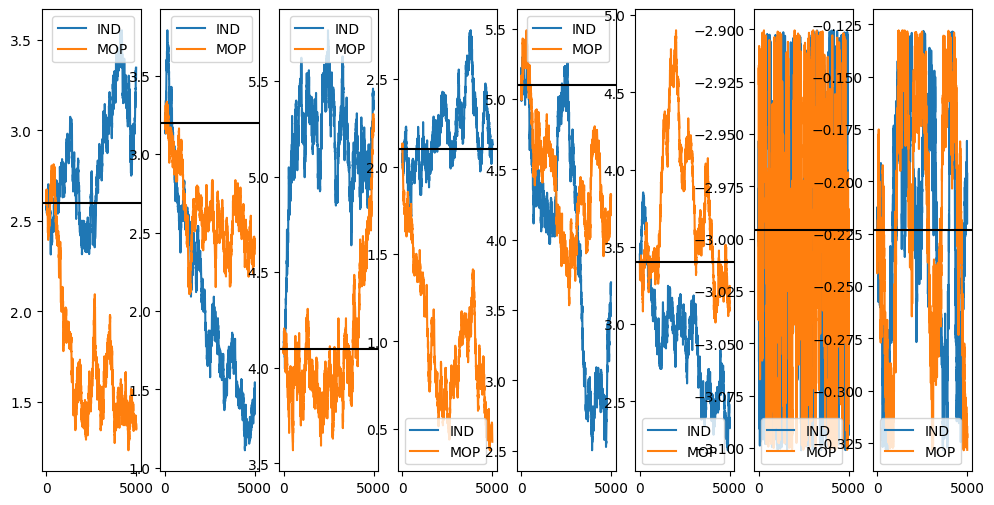

In [102]:
fig, ax = plt.subplots(1,len(theta0),figsize=(12,6))
print(ax)
for i in range(len(theta0)):
    ax[i].plot(chain_IND[i,:].detach(),label='IND')
    ax[i].plot(chain_MOP[i,:].detach(),label='MOP')
    ax[i].axhline(theta0[i],color='k')
    ax[i].legend()


<>:9: SyntaxWarning: invalid escape sequence '\T'
<>:9: SyntaxWarning: invalid escape sequence '\T'
C:\Users\colebanm\AppData\Local\Temp\ipykernel_29208\153864112.py:9: SyntaxWarning: invalid escape sequence '\T'
  plt.axvline(theta0[i].detach(), color='k', linestyle='--', label='True $\Theta_1$')


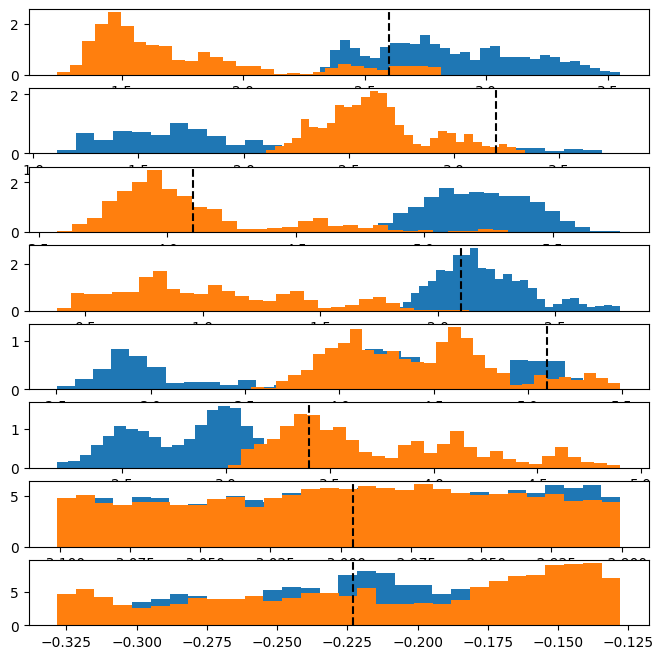

In [103]:
# Analyze the results
# Plot the results

plt.figure(figsize=(8, 8))
for i in range(num_par):
    plt.subplot(num_par, 1, i+1)
    plt.hist(chain_IND[i,:].detach(), bins=30, density=True)
    plt.hist(chain_MOP[i,:].detach(), bins=30, density=True)
    plt.axvline(theta0[i].detach(), color='k', linestyle='--', label='True $\Theta_1$')
   